FRONTEND SIGNAL PREVIEW:
{
  "input": "test24.jpg",
  "detections": [
    {
      "object": "pothole",
      "confidence": 0.72
    }
  ]
}
Image saved to: C:\Users\USER\Downloads\Obstacle_Detection_Project\drishti-final\detection_results\result_test24.jpg


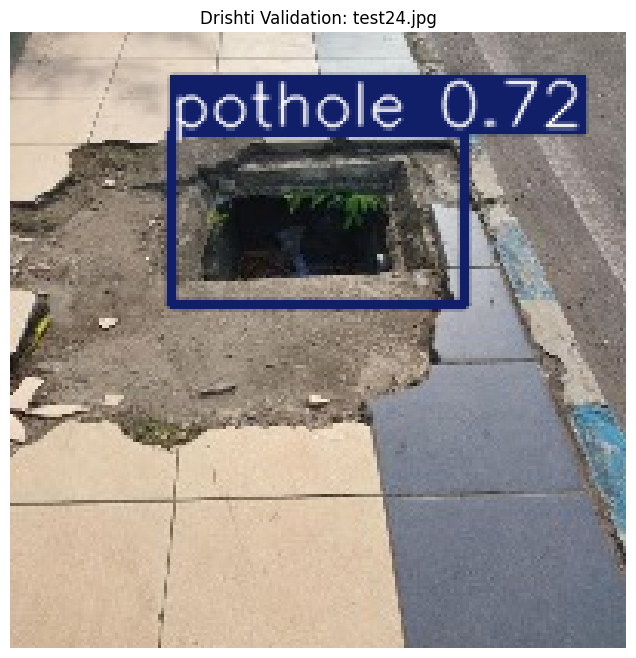

In [57]:
import cv2
import json
import os  
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. SETUP
MODEL_PATH = r'C:\Users\USER\Downloads\Obstacle_Detection_Project\drishti-final\ml_pipeline_Obstacle_det\runs\detect\Drishti_Final_Push\v11n_augmented_852\weights\best.pt'
IMAGE_NAME = 'test24.jpg' 
IMAGE_PATH = rf'C:\Users\USER\Downloads\Obstacle_Detection_Project\drishti-final\test_images\{IMAGE_NAME}'
OUTPUT_DIR = r'C:\Users\USER\Downloads\Obstacle_Detection_Project\drishti-final\detection_results'

# Create the results folder if it doesn't exist
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. LOAD MODEL & RUN AI
model = YOLO(MODEL_PATH)
results = model.predict(IMAGE_PATH, conf=0.1, verbose=False)
result = results[0]

# 3. GENERATE FRONTEND JSON SIGNAL
detections = []
for box in result.boxes:
    label = model.names[int(box.cls[0])]
    conf = float(box.conf[0])
    detections.append({"object": label, "confidence": round(conf, 2)})

print("FRONTEND SIGNAL PREVIEW:")
print(json.dumps({"input": IMAGE_NAME, "detections": detections}, indent=2))

# 4. VISUALIZE & SAVE RESULT
annotated_frame = result.plot()

# Save the detection image (OpenCV uses BGR)
save_path = os.path.join(OUTPUT_DIR, f"result_{IMAGE_NAME}")
cv2.imwrite(save_path, annotated_frame)
print(f"Image saved to: {save_path}")

# Display in Notebook (Convert BGR to RGB for correct colors)
rgb_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(rgb_frame)
plt.title(f"Drishti Validation: {IMAGE_NAME}")
plt.axis('off')
plt.show()